# 📊 Análisis de Sets con Exactamente 4 Runs NO-BAD

Este notebook procesa **sets con exactamente 4 runs que NO están marcados como 'BAD'** (pueden ser 'GOOD' o estar en blanco).

## 🔍 Filtros Aplicados:

1. ✅ **CalibSetNumber**: Solo valores enteros
2. ✅ **Filename**: Excluye runs con `_pre`, `_st`, `lar`
3. ✅ **Liquid Media**: Solo runs con `LN2`
4. ✅ **Selection**: Excluye runs marcados como `'BAD'`
5. ✅ **Número de runs**: Solo sets con **exactamente 4 runs** válidos

---

**Uso típico:** Análisis de sets con calibración completa estándar (4 runs no-BAD).

In [1]:
# Celda 1: Setup - Imports y configuración de paths
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Configurar path al repositorio
repo_root = Path('../..').resolve()
sys.path.insert(0, str(repo_root))

print(f'📁 Repo root: {repo_root}')

from RTD_Calibration_VGP.src.logfile import Logfile
from RTD_Calibration_VGP.src.set import Set
from RTD_Calibration_VGP.src.run import Run

print('✅ Módulos importados correctamente')

📁 Repo root: /Users/vicky/Desktop/rtd-calibration-ana
✅ Módulos importados correctamente


---
## 🔄 Recargar Módulo Actualizado

Ejecuta esta celda si modificaste el código fuente en `src/` para recargar los cambios sin reiniciar el kernel.

In [2]:
# Celda 2: Recargar módulo set.py (opcional, solo si hubo cambios)
import importlib
from RTD_Calibration_VGP.src import set as set_module
importlib.reload(set_module)
from RTD_Calibration_VGP.src.set import Set

print('✅ Módulo set.py recargado')

✅ Módulo set.py recargado


In [3]:
# Celda 3: Cargar y filtrar el logfile
logfile_path = repo_root / 'RTD_Calibration_VGP' / 'data' / 'LogFile.csv'

if not logfile_path.exists():
    raise FileNotFoundError(f'❌ LogFile no encontrado: {logfile_path}')

lf = Logfile(str(logfile_path))
df_original = lf.log_file.copy()

print(f'📊 LogFile cargado: {len(df_original)} filas totales')
print(f'\n📋 Distribución de Selection:')
print(df_original['Selection'].value_counts())

CSV file loaded successfully from '/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/LogFile.csv'.
📊 LogFile cargado: 792 filas totales

📋 Distribución de Selection:
Selection
GOOD    166
BAD      92
TRUE      1
Name: count, dtype: int64


---
## 🔍 Aplicar Filtros para Encontrar Sets con 4 Runs NO-BAD

In [4]:
# Celda 4: Aplicar filtros y encontrar sets con exactamente 4 runs NO-BAD
df_filtered = df_original.copy()

print('🔍 APLICANDO FILTROS...\n')
print(f'Filas iniciales: {len(df_filtered)}')

# Filtro 1: Liquid Media = LN2
before = len(df_filtered)
df_filtered = df_filtered[df_filtered['Liquid Media'] == 'LN2']
after = len(df_filtered)
print(f'✅ Filtro Liquid Media = LN2: {before} → {after} ({before - after} excluidas)')

# Filtro 2: CalibSetNumber entero
before = len(df_filtered)
df_filtered['CalibSetNumber'] = pd.to_numeric(df_filtered['CalibSetNumber'], errors='coerce')
df_filtered = df_filtered[df_filtered['CalibSetNumber'].notna()]
df_filtered = df_filtered[df_filtered['CalibSetNumber'] % 1 == 0]
after = len(df_filtered)
print(f'✅ Filtro CalibSetNumber entero: {before} → {after} ({before - after} excluidas)')

# Filtro 3: Excluir filenames con _pre, _st, lar
before = len(df_filtered)
df_filtered = df_filtered[~df_filtered['Filename'].str.contains('_pre', case=False, na=False)]
df_filtered = df_filtered[~df_filtered['Filename'].str.contains('_st', case=False, na=False)]
df_filtered = df_filtered[~df_filtered['Filename'].str.contains('lar', case=False, na=False)]
after = len(df_filtered)
print(f'✅ Filtro Filename (_pre, _st, lar): {before} → {after} ({before - after} excluidas)')

# Filtro 4: Excluir Selection = 'BAD'
before = len(df_filtered)
df_filtered = df_filtered[df_filtered['Selection'] != 'BAD']
after = len(df_filtered)
print(f'✅ Filtro Selection != BAD: {before} → {after} ({before - after} excluidas)')

print(f'\n📊 FILAS FINALES DESPUÉS DE FILTROS: {len(df_filtered)}')

# Contar runs por CalibSetNumber
counts = df_filtered.groupby('CalibSetNumber').size().sort_index()

# Filtrar sets con EXACTAMENTE 4 runs
sets_with_4 = counts[counts == 4]

print(f'\n📈 SETS CON EXACTAMENTE 4 RUNS NO-BAD: {len(sets_with_4)}')
print(f'IDs: {sorted([int(x) for x in sets_with_4.index])}')

# Guardar lista para usar después
sets_eq_4 = sorted([int(x) for x in sets_with_4.index])

🔍 APLICANDO FILTROS...

Filas iniciales: 792
✅ Filtro Liquid Media = LN2: 792 → 703 (89 excluidas)
✅ Filtro CalibSetNumber entero: 703 → 652 (51 excluidas)
✅ Filtro Filename (_pre, _st, lar): 652 → 321 (331 excluidas)
✅ Filtro Selection != BAD: 321 → 240 (81 excluidas)

📊 FILAS FINALES DESPUÉS DE FILTROS: 240

📈 SETS CON EXACTAMENTE 4 RUNS NO-BAD: 55
IDs: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 58, 59, 60]


---
## 📊 Visualización: Distribución de Runs por Set

✅ Gráfico guardado: outputs/set_4runs_no_bad/runs_per_set_4_no_bad.png


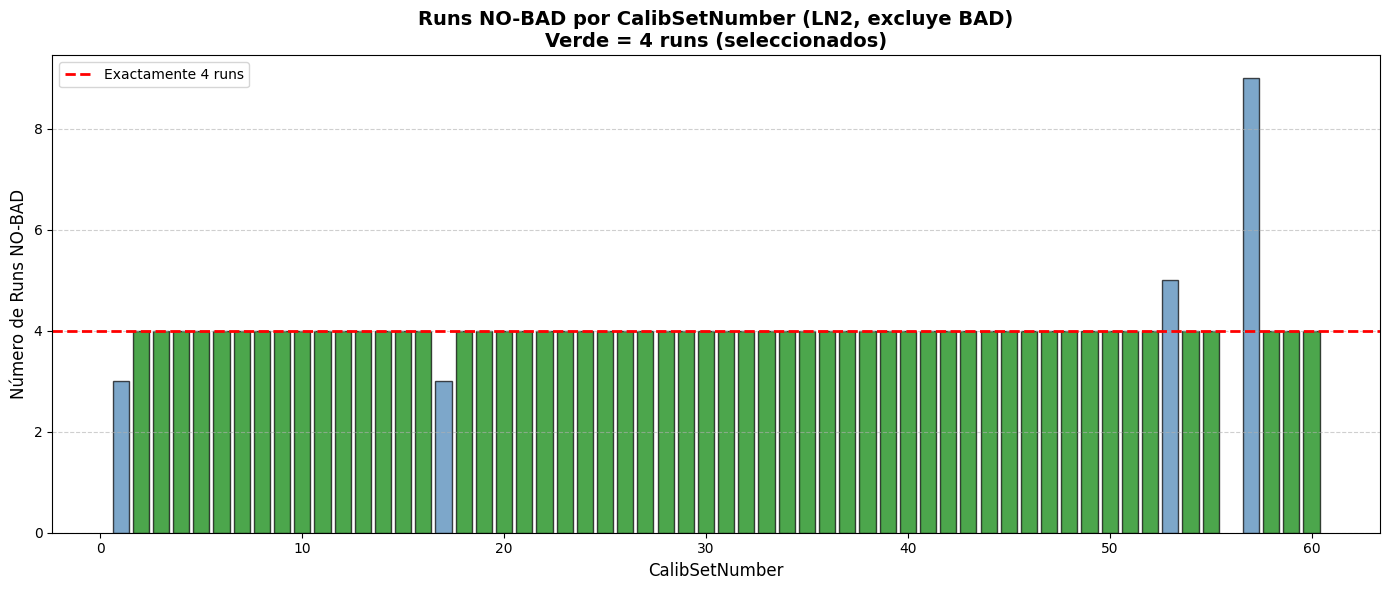

In [5]:
# Celda 5: Gráfico de barras - Runs por CalibSetNumber (destacando los de 4 runs)
plt.figure(figsize=(14, 6))

colors = ['green' if c == 4 else 'steelblue' for c in counts.values]
plt.bar([int(x) for x in counts.index], counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.axhline(y=4, color='red', linestyle='--', linewidth=2, label='Exactamente 4 runs')

plt.xlabel('CalibSetNumber', fontsize=12)
plt.ylabel('Número de Runs NO-BAD', fontsize=12)
plt.title('Runs NO-BAD por CalibSetNumber (LN2, excluye BAD)\nVerde = 4 runs (seleccionados)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Guardar
output_dir = Path('outputs/set_4runs_no_bad')
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'runs_per_set_4_no_bad.png'
plt.savefig(output_path, dpi=150)
print(f'✅ Gráfico guardado: {output_path}')
plt.show()

---
## 🔧 Procesar Sets Seleccionados

In [6]:
# Celda 6: Crear Set instance y agrupar runs
s = Set(lf.log_file)

# Agrupar SOLO los sets con exactamente 4 runs NO-BAD
# Pasamos la lista de sets seleccionados
s.group_runs_by_set(selected_sets=[float(x) for x in sets_eq_4])

print(f'\n📦 Sets agrupados: {len(s.runs_by_set)}')
for set_num, runs in s.runs_by_set.items():
    print(f'  Set {int(set_num)}: {len(runs)} runs')


Processing CalibSetNumber: 2.0
    Excluded: 05042022_ln2_r48176_r48177_48190-48201_1_pre (contains 'pre' or 'st')
Temperature file found: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/RTD_Calibs/CalSetN_2/05042022_ln2_r48176_r48177_48190-48201_1.txt
Columns with excessive NaNs: ['channel_8']
Temperature file processed successfully: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/RTD_Calibs/CalSetN_2/05042022_ln2_r48176_r48177_48190-48201_1.txt
Associated sensors: {'channel_1': '48190', 'channel_2': '48191', 'channel_3': '48192', 'channel_4': '48193', 'channel_5': '48194', 'channel_6': '48195', 'channel_7': '48196', 'channel_8': '48197', 'channel_9': '48198', 'channel_10': '48199', 'channel_11': '48200', 'channel_12': '48201', 'channel_13': '48176', 'channel_14': '48177'}
Detected faulty channels:
 - 48197: min below 70 K, contains NaN
    Included: 05042022_ln2_r48176_r48177_48190-48201_1
    Excluded: 05042022

In [7]:
# Celda 7: Calcular offsets y RMS
print('🔄 Calculando offsets y RMS...\n')
s.calculate_offsets_and_rms(selected_sets=[float(x) for x in sets_eq_4])
print('\n✅ Offsets y RMS calculados')

🔄 Calculando offsets y RMS...


Processing CalibSetNumber: 2.0
Reference run has 14 sensors: 05042022_ln2_r48176_r48177_48190-48201_1
Reference sensor mapping:
Sensor_mapping : {'channel_1': '48190', 'channel_2': '48191', 'channel_3': '48192', 'channel_4': '48193', 'channel_5': '48194', 'channel_6': '48195', 'channel_7': '48196', 'channel_8': '48197', 'channel_9': '48198', 'channel_10': '48199', 'channel_11': '48200', 'channel_12': '48201', 'channel_13': '48176', 'channel_14': '48177'}
Reference based on run: 05042022_ln2_r48176_r48177_48190-48201_1 with sensors: ['48190', '48191', '48192', '48193', '48194', '48195', '48196', '48197', '48198', '48199', '48200', '48201', '48176', '48177']
  Processing Run: 05042022_ln2_r48176_r48177_48190-48201_1
Current sensors: ['48190', '48191', '48192', '48193', '48194', '48195', '48196', '48197', '48198', '48199', '48200', '48201', '48176', '48177']
Mean offsets computed.
RMS errors computed.
  → ORIGINAL offsets matrix:
           48190      48191

---
## 📈 Generar Plots de Repeatability

In [8]:
# Celda 8: Generar plots de repeatability
output_dir = Path('outputs/set_4runs_no_bad')
output_dir.mkdir(parents=True, exist_ok=True)

print('🔄 Generando plots de repeatability...\n')

s.offset_repeatability(
    selected_sets=[float(x) for x in sets_eq_4],
    ref=2,  # Sensor de referencia (o 'auto' para dinámico)
    save_dir=str(output_dir),
    write_csv=False,   # No generar CSVs
    write_excel=False  # No generar Excel
)

print(f'\n✅ Plots generados en: {output_dir}')

🔄 Generando plots de repeatability...


Processing CalibSetNumber: 2.0
INFO: Set 2.0: Using fixed reference channel 2 → Sensor ID 48191
  [Sensor Ch 1 vs Ref Ch 2 | Run 1] Mean: 830.758 mK, Std: 0.296 mK
  [Sensor Ch 1 vs Ref Ch 2 | Run 2] Mean: 830.642 mK, Std: 0.261 mK
  [Sensor Ch 1 vs Ref Ch 2 | Run 3] Mean: 830.753 mK, Std: 0.253 mK
  [Sensor Ch 1 vs Ref Ch 2 | Run 4] Mean: 830.398 mK, Std: 0.491 mK
  [Sensor Ch 2 vs Ref Ch 2 | Run 1] Mean: 0.000 mK, Std: 0.000 mK
  [Sensor Ch 2 vs Ref Ch 2 | Run 2] Mean: 0.000 mK, Std: 0.000 mK
  [Sensor Ch 2 vs Ref Ch 2 | Run 3] Mean: 0.000 mK, Std: 0.000 mK
  [Sensor Ch 2 vs Ref Ch 2 | Run 4] Mean: 0.000 mK, Std: 0.000 mK
  [Sensor Ch 3 vs Ref Ch 2 | Run 1] Mean: 739.216 mK, Std: 0.263 mK
  [Sensor Ch 3 vs Ref Ch 2 | Run 2] Mean: 739.475 mK, Std: 0.309 mK
  [Sensor Ch 3 vs Ref Ch 2 | Run 3] Mean: 739.880 mK, Std: 0.272 mK
  [Sensor Ch 3 vs Ref Ch 2 | Run 4] Mean: 739.753 mK, Std: 0.365 mK
  [Sensor Ch 4 vs Ref Ch 2 | Run 1] Mean: 832.136 mK, St

/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/set.py:701: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend(fontsize=8, loc="upper left", ncol=1)


Plot saved to: outputs/set_4runs_no_bad/offset_repeatability_set_30.0.png

Processing CalibSetNumber: 31.0
OK: Set 31.0: Using dynamic references from raised sensors in channels [3, 9]
  [Sensor Ch 1 vs Ref Ch 3 | Run 1] Mean: 253.407 mK, Std: 0.741 mK
  [Sensor Ch 1 vs Ref Ch 3 | Run 2] Mean: 250.278 mK, Std: 0.339 mK
  [Sensor Ch 1 vs Ref Ch 3 | Run 3] Mean: 245.080 mK, Std: 0.316 mK
  [Sensor Ch 1 vs Ref Ch 3 | Run 4] Mean: 245.703 mK, Std: 0.485 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 1] Mean: 227.953 mK, Std: 0.638 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 2] Mean: 230.148 mK, Std: 0.260 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 3] Mean: 228.734 mK, Std: 0.258 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 4] Mean: 229.655 mK, Std: 0.345 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 1] Mean: -284.920 mK, Std: 0.738 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 2] Mean: -287.318 mK, Std: 0.342 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 3] Mean: -283.702 mK, Std: 0.319 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 4] Mean: -286.864 mK, Std: 0.62

---
## 📊 Generar Plots Globales (Opcional)

🔄 Generando plots globales de means...

Processing 55 sets.
Set 2.0: len sensor_names=10, len global_means=10
  First sensor_name: '48190' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(830.6866205434924) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 3.0: len sensor_names=9, len global_means=9
  First sensor_name: '48060' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-66.35545269405011) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 4.0: len sensor_names=9, len global_means=9
  First sensor_name: '48480' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-13.924798414992452) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 5.0: len sensor_names=10, len global_means=10
  First sensor_name: '48492' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-33.899152223

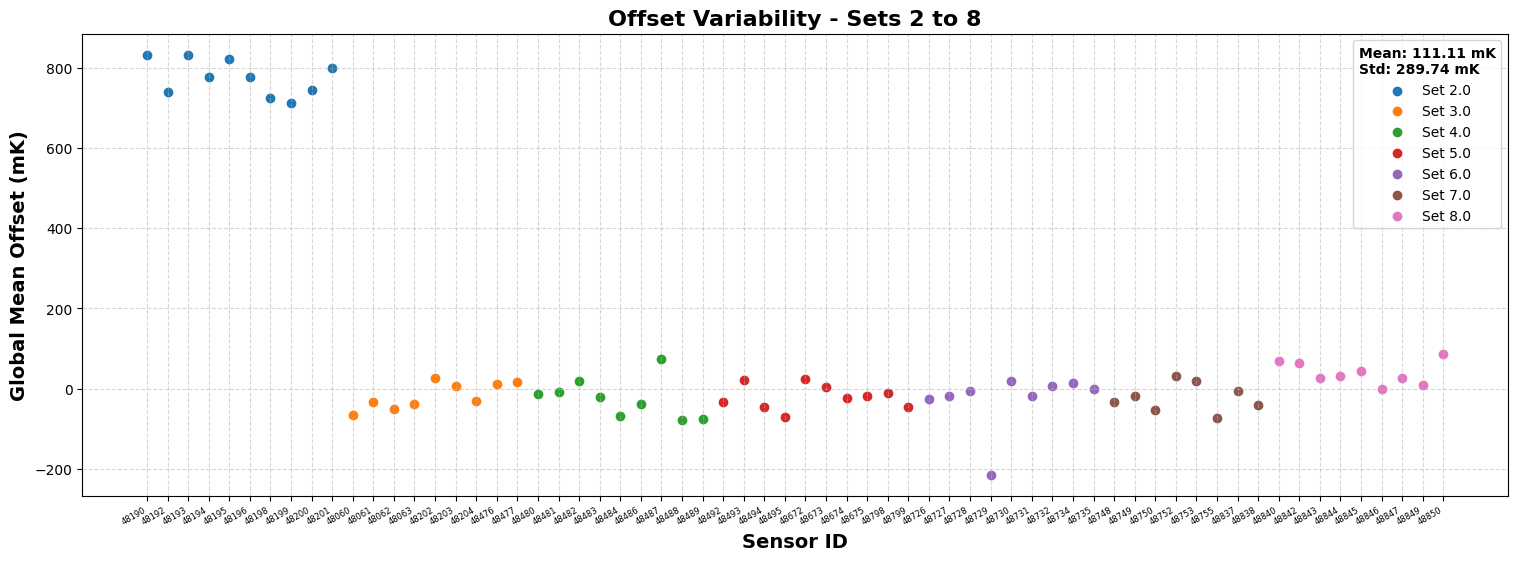

Set 9.0: len sensor_names=11, len global_means=11
  First sensor_name: '48852' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(176.30075072459772) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 10.0: len sensor_names=11, len global_means=11
  First sensor_name: '48864' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(510.161061460056) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 11.0: len sensor_names=11, len global_means=11
  First sensor_name: '48876' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(474.5711616109265) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 12.0: len sensor_names=11, len global_means=11
  First sensor_name: '48888' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-41.90747332782698) (type: <class 'numpy.float64'>)
  All global_mean

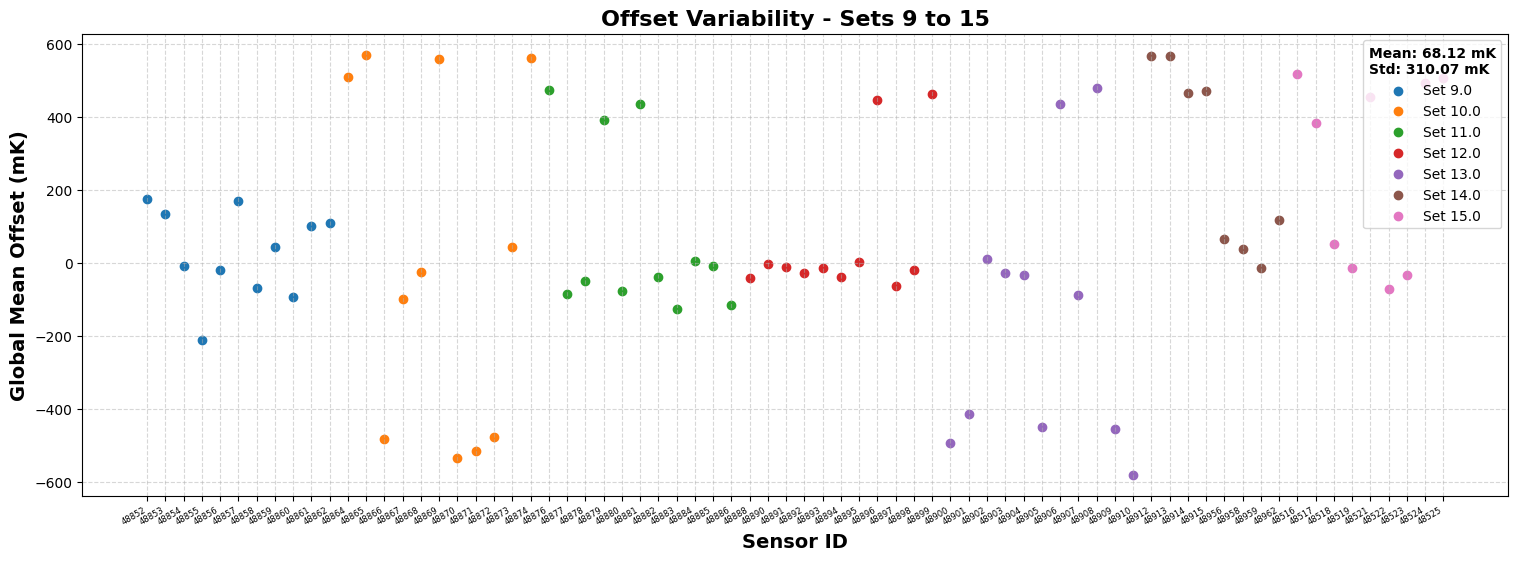

Set 16.0: len sensor_names=9, len global_means=9
  First sensor_name: '49101' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(549.3242143580708) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 18.0: len sensor_names=10, len global_means=10
  First sensor_name: '49125' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(46.25990699789376) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 19.0: len sensor_names=10, len global_means=10
  First sensor_name: '49167' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-23.077077230149744) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 20.0: len sensor_names=11, len global_means=11
  First sensor_name: '49179' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-22.876541138700684) (type: <class 'numpy.float64'>)
  All global_me

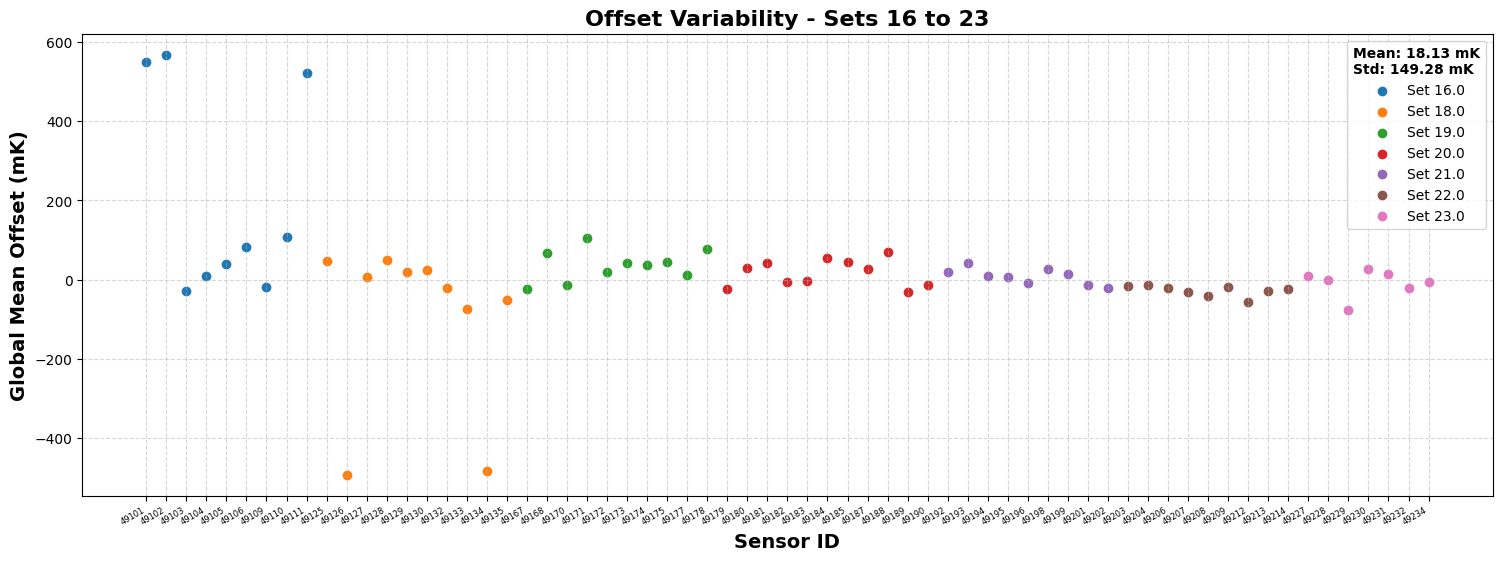

Set 24.0: len sensor_names=10, len global_means=10
  First sensor_name: '49238' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(43.43578343792494) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 25.0: len sensor_names=9, len global_means=9
  First sensor_name: '49250' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(5.353061249734044) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 26.0: len sensor_names=8, len global_means=8
  First sensor_name: '55069' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-75.36147611951102) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 27.0: len sensor_names=8, len global_means=8
  First sensor_name: '54880' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(18.509297143718772) (type: <class 'numpy.float64'>)
  All global_mean typ

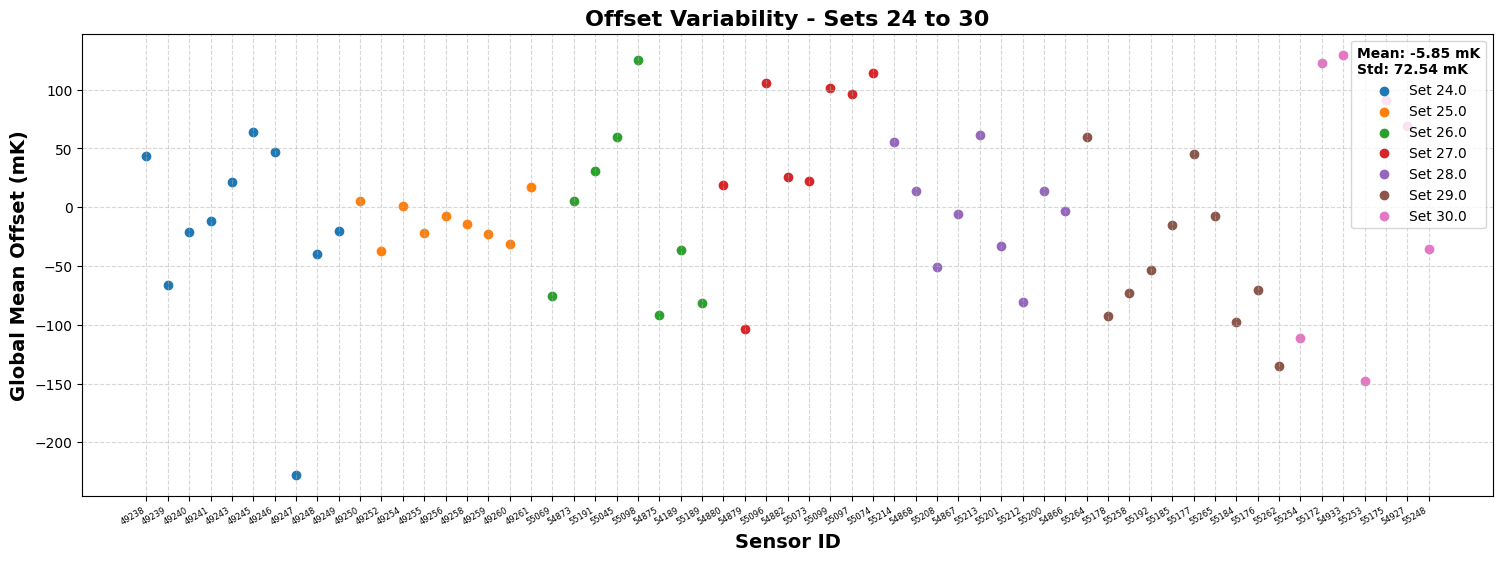

Set 31.0: len sensor_names=10, len global_means=10
  First sensor_name: '55179' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(229.39273056790006) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 32.0: len sensor_names=10, len global_means=10
  First sensor_name: '55247' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-43.748213067542714) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 33.0: len sensor_names=10, len global_means=10
  First sensor_name: '55167' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-94.67676104083002) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 34.0: len sensor_names=11, len global_means=11
  First sensor_name: '54878' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(20.90902421148625) (type: <class 'numpy.float64'>)
  All global_

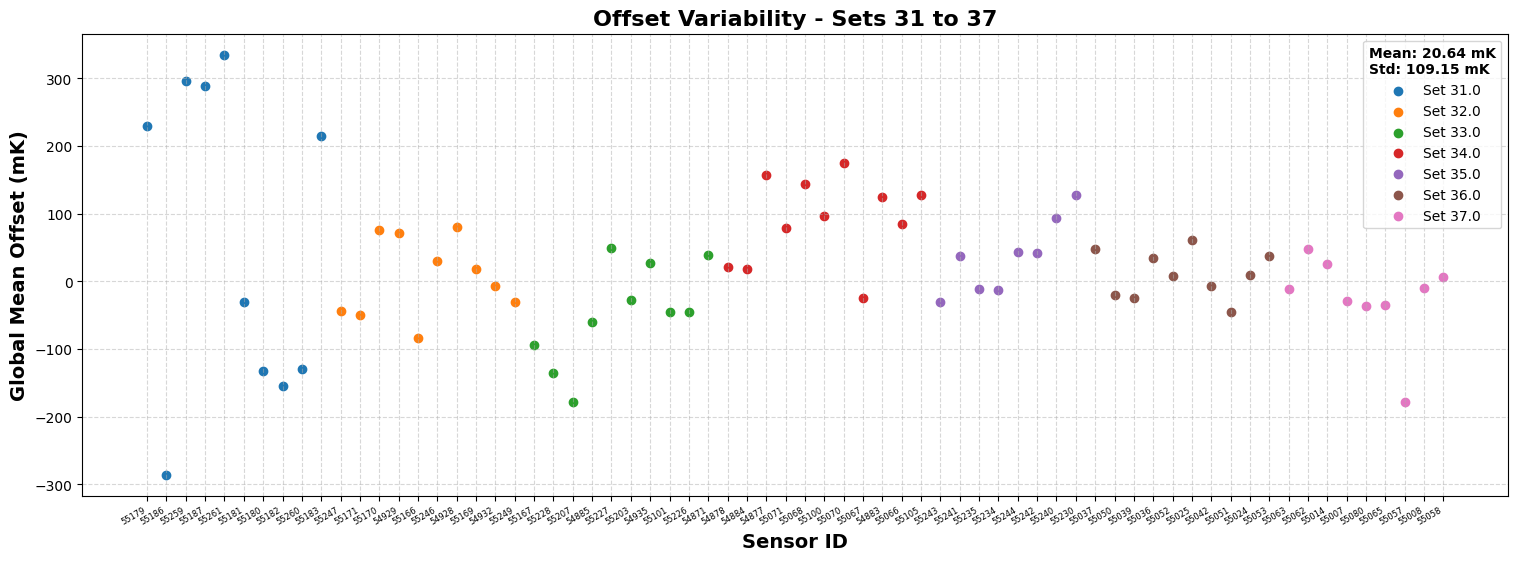

Set 38.0: len sensor_names=10, len global_means=10
  First sensor_name: '55218' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(35.93507613274094) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 39.0: len sensor_names=11, len global_means=11
  First sensor_name: '55238' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(102.02864675880144) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 40.0: len sensor_names=10, len global_means=10
  First sensor_name: '55206' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(96.61793022956275) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 41.0: len sensor_names=11, len global_means=11
  First sensor_name: '54896' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(746.1446600075965) (type: <class 'numpy.float64'>)
  All global_mea

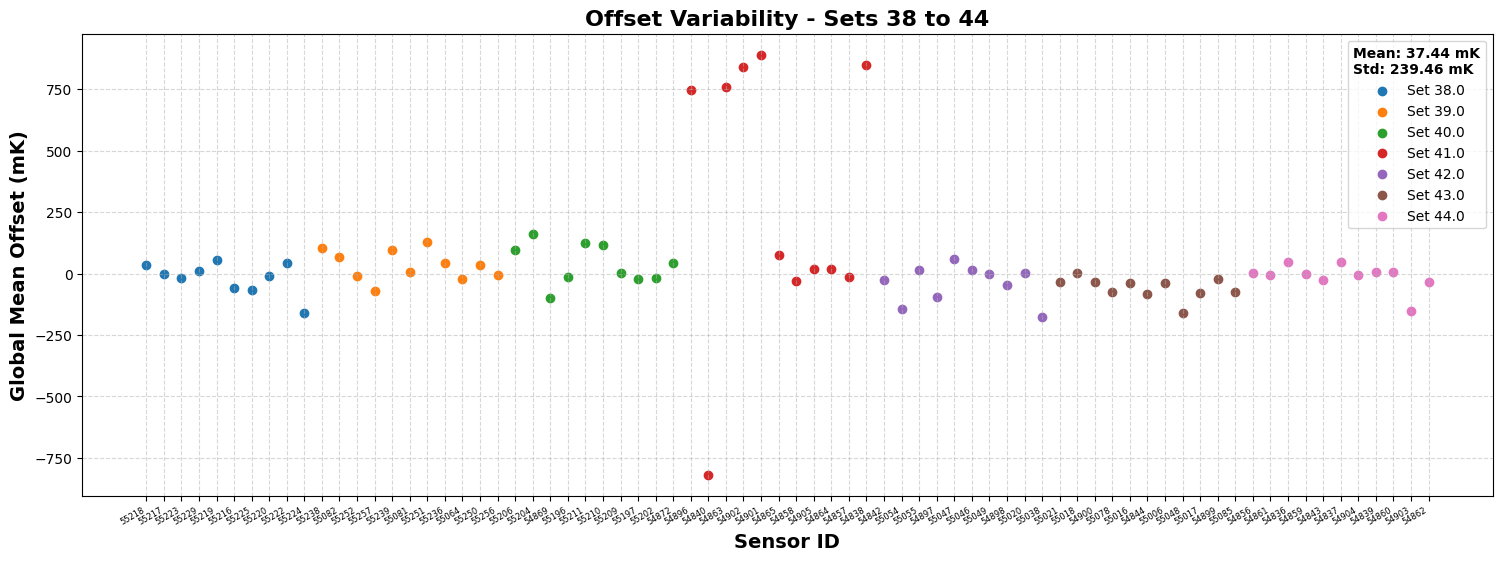

Set 45.0: len sensor_names=11, len global_means=11
  First sensor_name: '55056' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-12.841195984016062) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 46.0: len sensor_names=10, len global_means=10
  First sensor_name: '48957' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-593.6558416578946) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 47.0: len sensor_names=10, len global_means=10
  First sensor_name: '55190' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(3.777899346017095) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 48.0: len sensor_names=10, len global_means=10
  First sensor_name: '55231' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(162.17944770715914) (type: <class 'numpy.float64'>)
  All global_

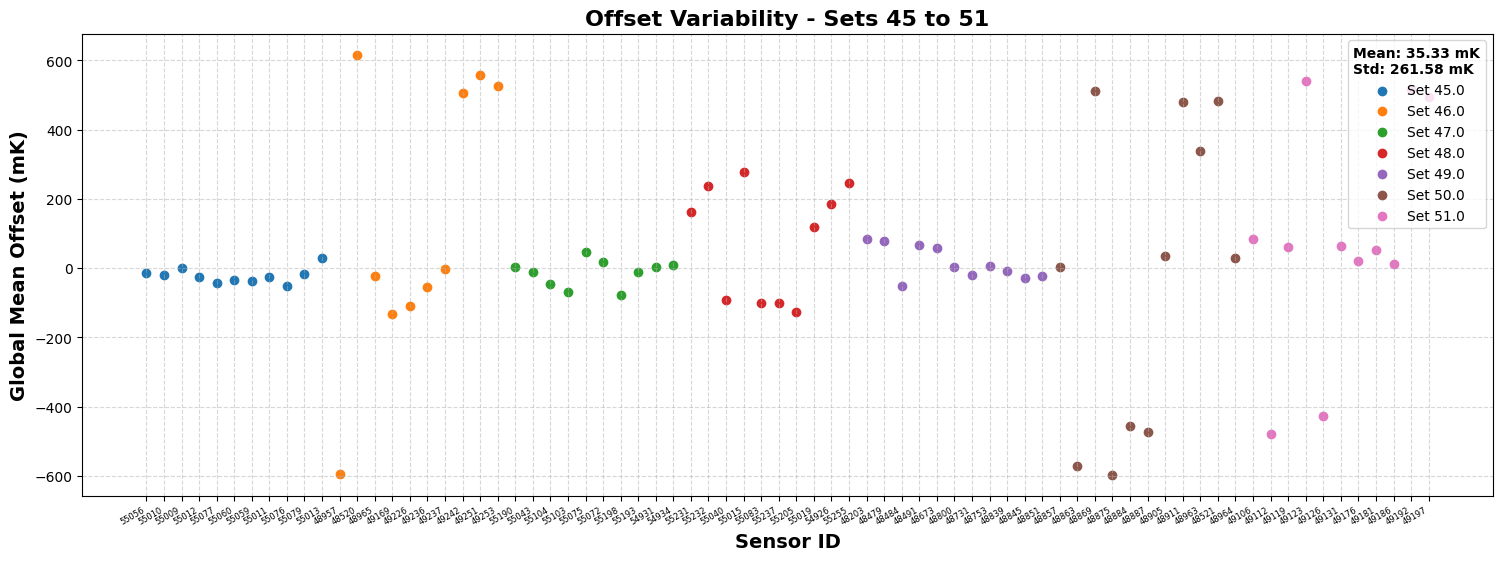

Set 52.0: len sensor_names=11, len global_means=11
  First sensor_name: '49204' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(557.4797904736711) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 54.0: len sensor_names=11, len global_means=11
  First sensor_name: '54876' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-32.02924497802756) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 55.0: len sensor_names=11, len global_means=11
  First sensor_name: '54869' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-95.87204610846507) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 58.0: len sensor_names=11, len global_means=11
  First sensor_name: '48176' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(526.6657291813706) (type: <class 'numpy.float64'>)
  All global_me

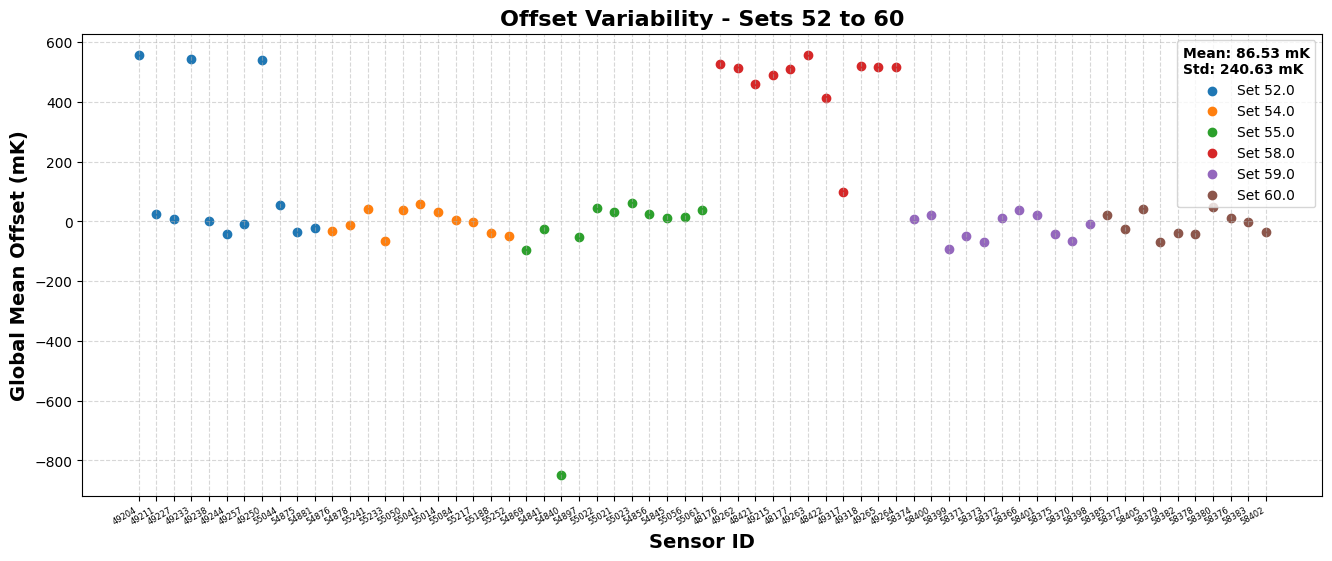


✅ Plots globales guardados en: outputs/set_4runs_no_bad/global_means


In [9]:
# Celda 9: Plot global de means (opcional)
global_means_dir = output_dir / 'global_means'
global_means_dir.mkdir(parents=True, exist_ok=True)

print('🔄 Generando plots globales de means...\n')

s.plot_global_means(
    selected_sets=[float(x) for x in sets_eq_4],
    save_dir=str(global_means_dir)
)

print(f'\n✅ Plots globales guardados en: {global_means_dir}')

🔄 Generando histogramas globales de sigmas...

Processing 55 sets.


/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/set.py:1444: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=legend_title, title_fontproperties={'weight': 'bold'}, loc='upper left')


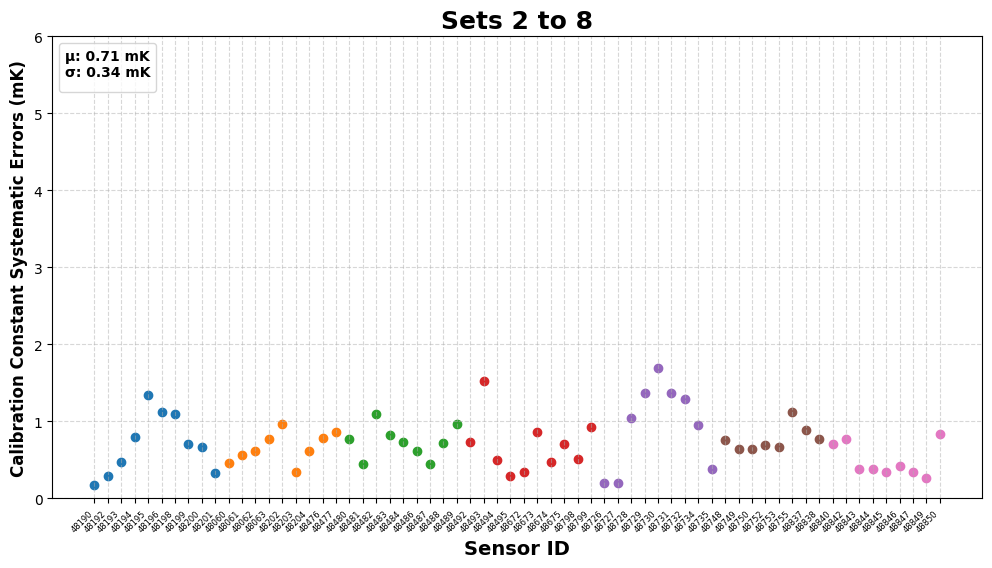

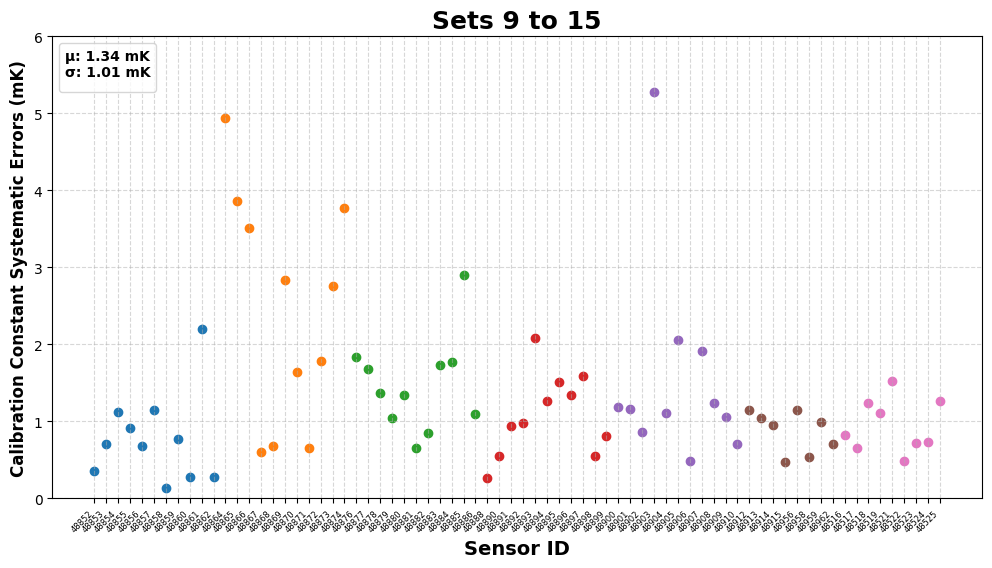

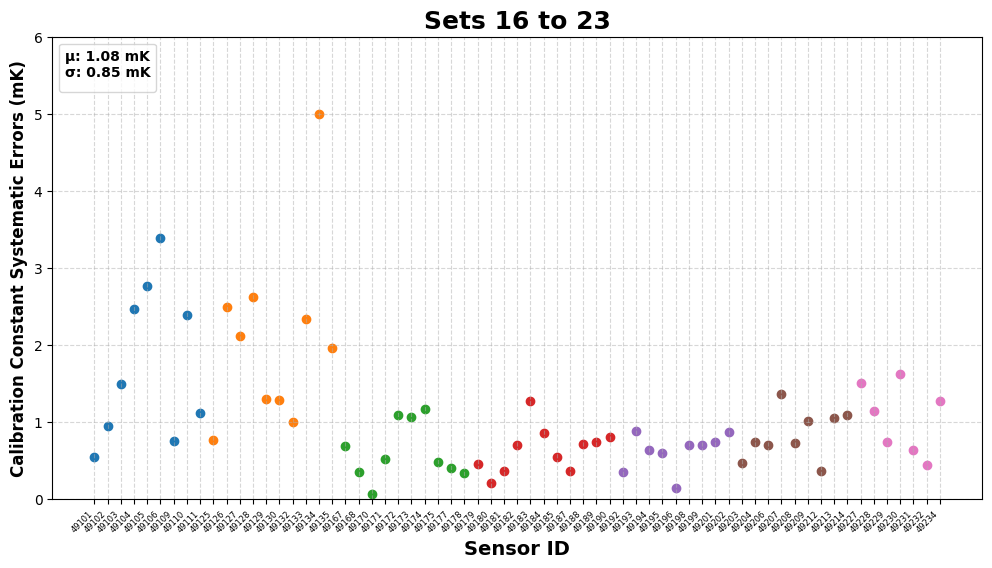

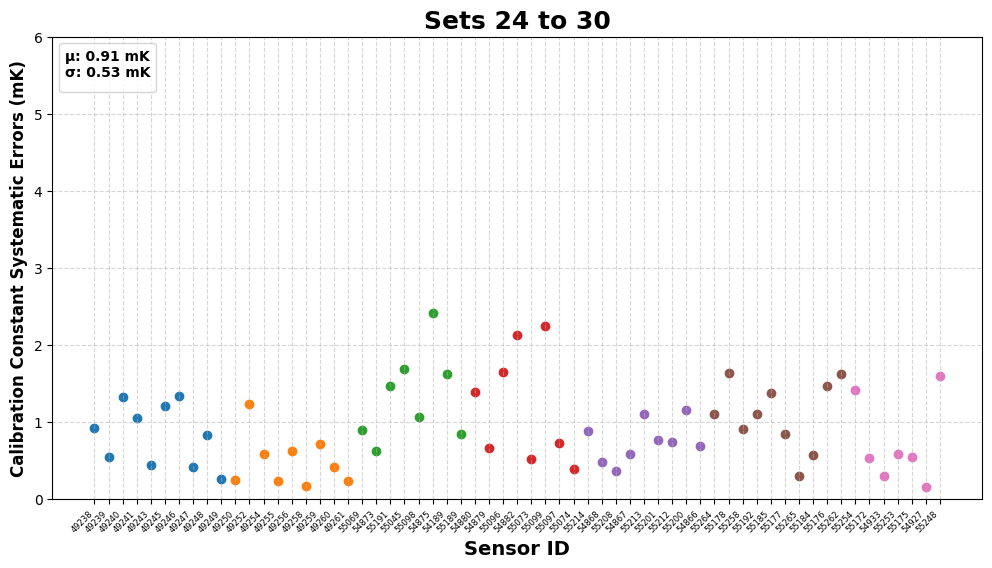

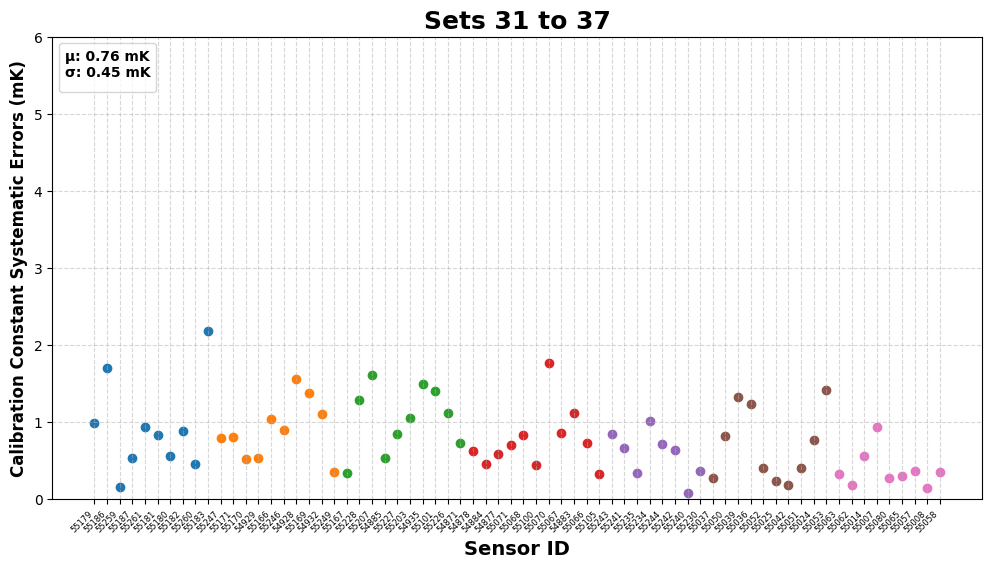

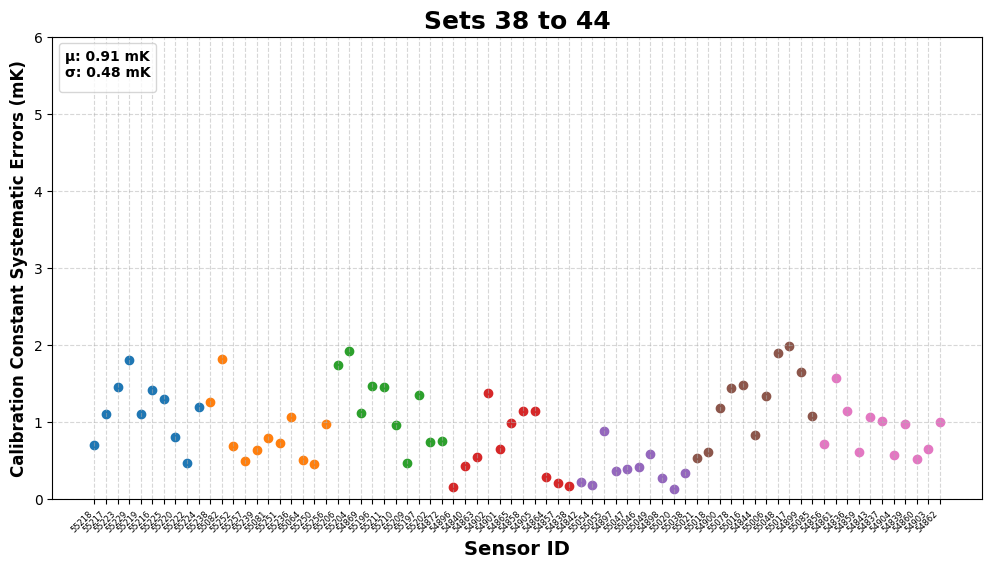

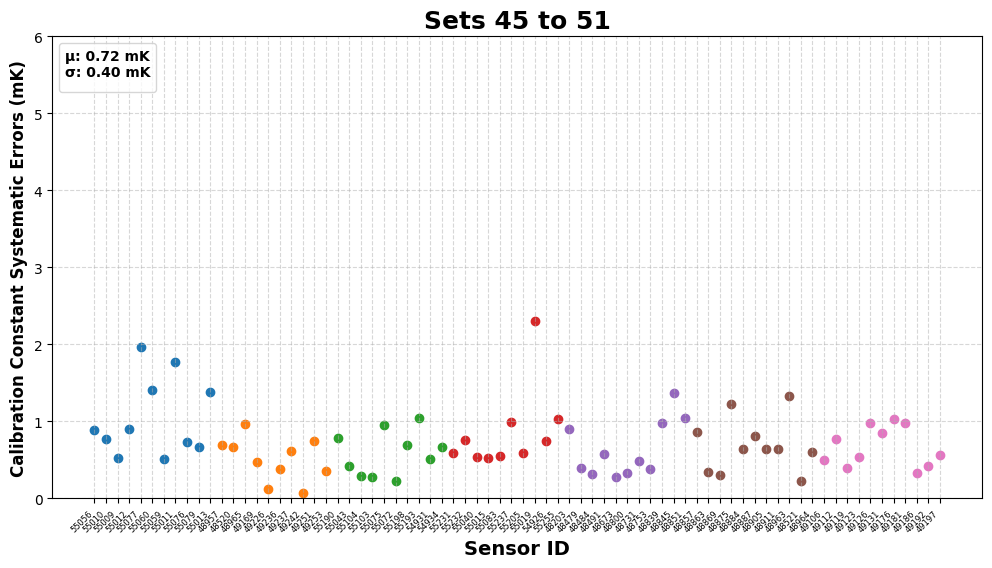

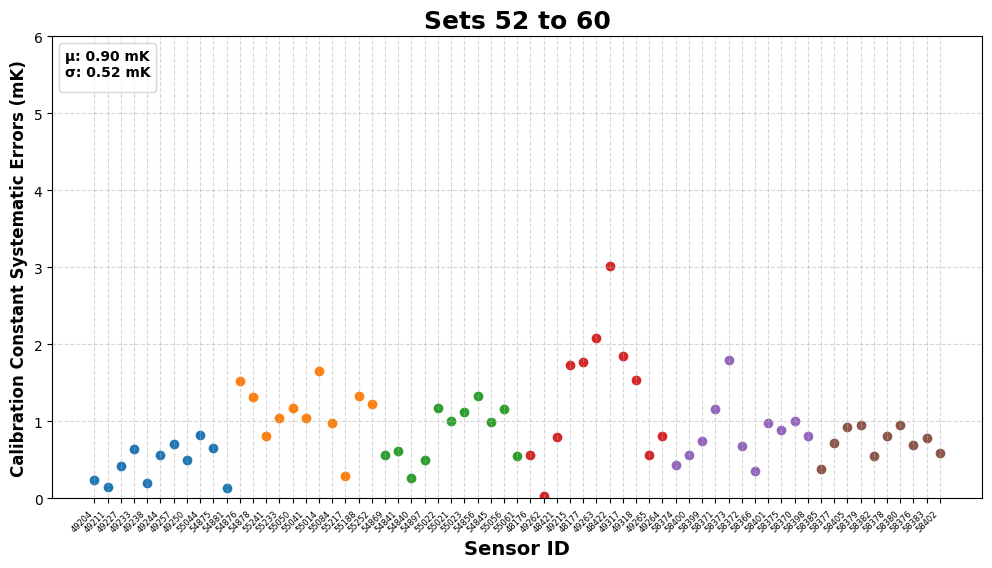

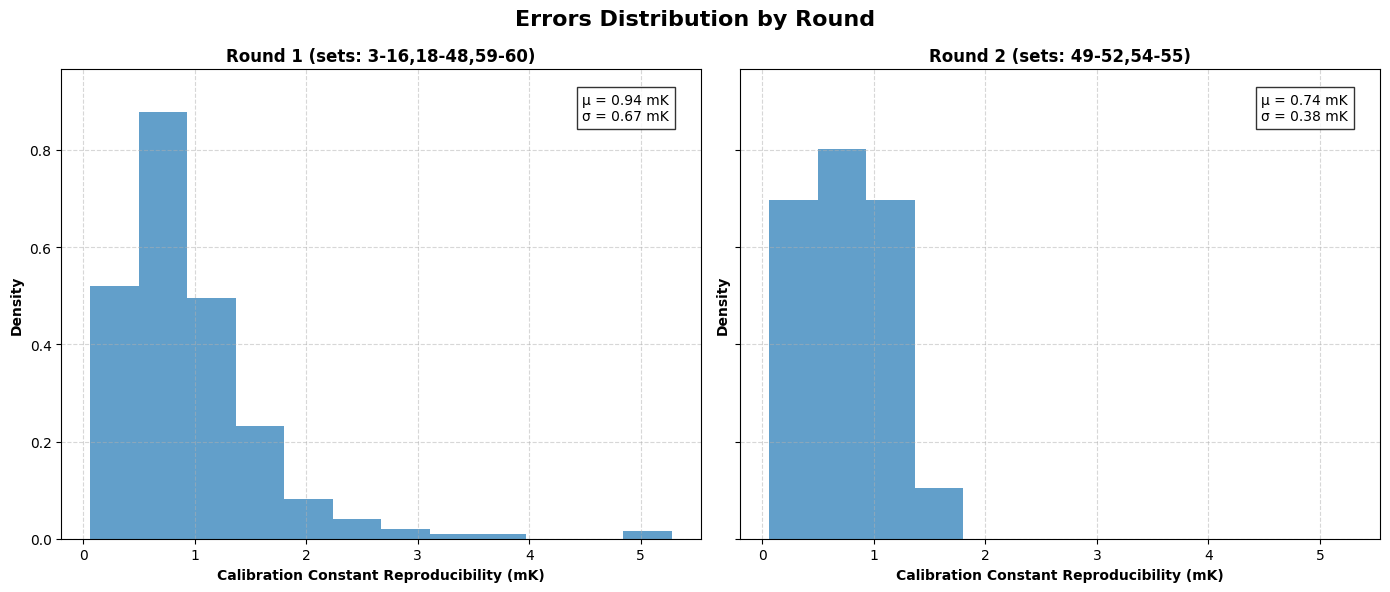

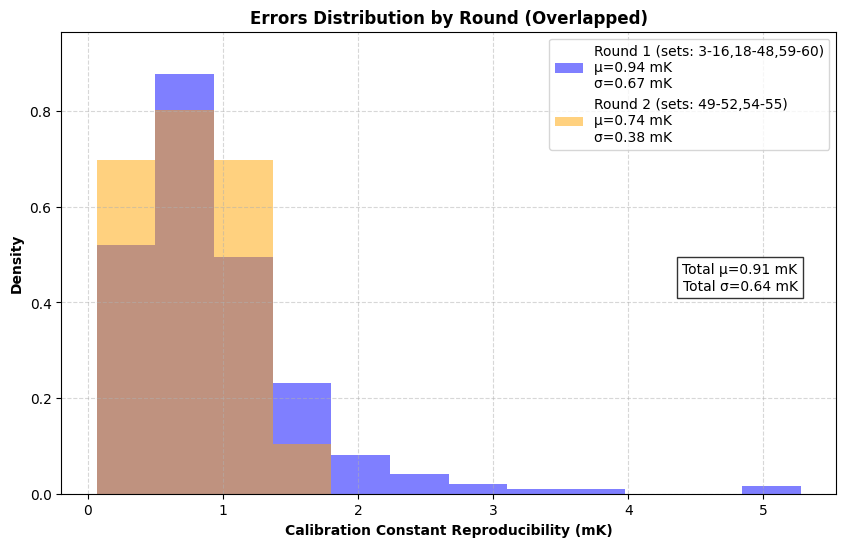

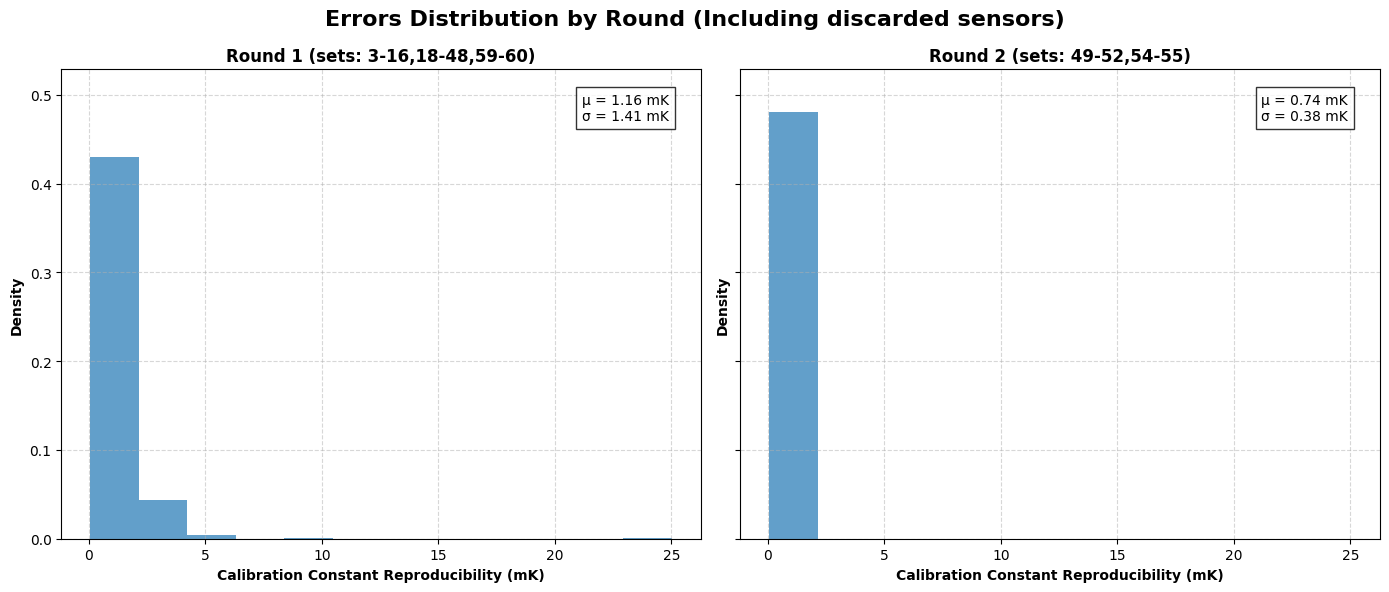

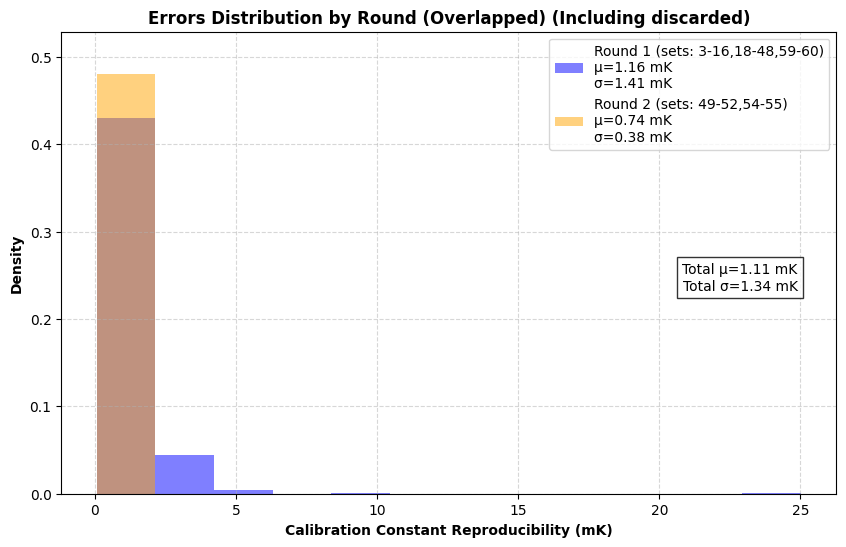


✅ Histogramas guardados en: outputs/set_4runs_no_bad/global_sigmas


In [10]:
# Celda 10: Plot global de sigmas (opcional)
global_sigmas_dir = output_dir / 'global_sigmas'
global_sigmas_dir.mkdir(parents=True, exist_ok=True)

print('🔄 Generando histogramas globales de sigmas...\n')

s.plot_global_sigmas(
    selected_sets=[float(x) for x in sets_eq_4],
    save_dir=str(global_sigmas_dir)
)

print(f'\n✅ Histogramas guardados en: {global_sigmas_dir}')

---
## 📋 Resumen de Resultados

In [11]:
# Celda 11: Resumen final
import os

print('='*60)
print('✅ ANÁLISIS COMPLETADO')
print('='*60)

print(f'\n📊 Sets procesados: {len(sets_eq_4)}')
print(f'IDs: {sets_eq_4}')

print(f'\n📁 Directorio de salida: {output_dir}')

# Contar archivos generados
png_files = list(output_dir.rglob('*.png'))
csv_files = list(output_dir.rglob('*.csv'))

print(f'\n📄 Archivos generados:')
print(f'  • PNGs: {len(png_files)}')
print(f'  • CSVs: {len(csv_files)}')

# Listar subdirectorios de repeatability
repeatability_dirs = [d for d in output_dir.iterdir() if d.is_dir() and d.name.startswith('repeatability_set_')]
print(f'  • Sets con plots: {len(repeatability_dirs)}')

print('\n🎯 Para abrir los resultados:')
print(f'   open {output_dir}')

print('='*60)

✅ ANÁLISIS COMPLETADO

📊 Sets procesados: 55
IDs: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 58, 59, 60]

📁 Directorio de salida: outputs/set_4runs_no_bad

📄 Archivos generados:
  • PNGs: 76
  • CSVs: 1
  • Sets con plots: 0

🎯 Para abrir los resultados:
   open outputs/set_4runs_no_bad


---

## 📝 Notas

### Criterios de Selección:
- ✅ Solo runs con `Liquid Media == 'LN2'`
- ✅ Solo `CalibSetNumber` enteros
- ✅ Excluye filenames con `_pre`, `_st`, `lar`
- ✅ **Excluye runs con `Selection == 'BAD'`**
- ✅ **Solo sets con exactamente 4 runs** después de filtros

### Diferencias con ANALYSIS_ALL_SETS_LN2.ipynb:
- Este notebook **excluye runs BAD**
- Solo procesa sets con **exactamente 4 runs** (no ≥4)
- Más enfocado en análisis estándar/nominal

### Modificaciones Comunes:
1. **Cambiar número de runs:** Modifica `counts == 4` en celda 4
2. **Incluir runs BAD:** Comenta la línea `df_filtered = df_filtered[df_filtered['Selection'] != 'BAD']`
3. **Cambiar liquid media:** Cambia `'LN2'` a `'LAr'` en celda 4
4. **Cambiar sensor de referencia:** Modifica `ref=2` en celda 8

### Troubleshooting:
- Si no encuentras sets: verifica que haya suficientes runs NO-BAD de LN2
- Si el código no refleja cambios: ejecuta celda 2 (reload)
- Si faltan plots: verifica que `outputs/set_4runs_no_bad/` exista